In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 1 — Imports & Setup
# ═══════════════════════════════════════════════════════════
import os, json, shutil, random, time, yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

# Reproducibility — same results every run
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow :', tf.__version__)
print('GPU        :', tf.config.list_physical_devices('GPU'))
print('All imports successful')

TensorFlow : 2.19.0
GPU        : []
All imports successful


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 2 — Mount Google Drive
# ═══════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 3 — Verify dataset path
# ═══════════════════════════════════════════════════════════

BASE_DIR = '/content/drive/MyDrive/Colab_Notebooks/AIML_PROJECT/Multicrop_Disease_Dataset'

print('Checking path...')
print(f'EXISTS : {os.path.exists(BASE_DIR)}')

if os.path.exists(BASE_DIR):
    contents = os.listdir(BASE_DIR)
    print(f'\nContents of your dataset folder:')
    for item in sorted(contents):
        print(f'  {item}')
else:
    print('\nFolder not found!')

Checking path...
EXISTS : True

Contents of your dataset folder:
  README.roboflow.txt
  data.yaml
  test
  train
  valid


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 4 — Configure all paths
# ═══════════════════════════════════════════════════════════

# ── Original YOLO split folders on Drive ──────────────────
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VALID_DIR = os.path.join(BASE_DIR, 'valid')
TEST_DIR  = os.path.join(BASE_DIR, 'test')
YAML_PATH = os.path.join(BASE_DIR, 'data.yaml')

# ── Local Colab SSD paths (fast, temporary) ───────────────
LOCAL_BASE  = '/content/local_dataset'
LOCAL_TRAIN = os.path.join(LOCAL_BASE, 'train')
LOCAL_VALID = os.path.join(LOCAL_BASE, 'valid')
LOCAL_TEST  = os.path.join(LOCAL_BASE, 'test')

# ── Classification output folders (on local SSD) ──────────
TRAIN_CLS = os.path.join(LOCAL_BASE, 'train_cls')
VALID_CLS = os.path.join(LOCAL_BASE, 'valid_cls')
TEST_CLS  = os.path.join(LOCAL_BASE, 'test_cls')

# ── Model output paths ────────────────────────────────────
MODEL_PATH   = '/content/plant_disease_model.h5'
CLASSES_PATH = '/content/class_names.json'

# ── Image & training settings ─────────────────────────────
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS     = 30
LR         = 0.01
MOMENTUM   = 0.9

# ── Verify all Drive folders exist ────────────────────────
print('Drive folders:')
for label, path in [('train', TRAIN_DIR), ('valid', VALID_DIR),
                    ('test',  TEST_DIR),  ('yaml',  YAML_PATH)]:
    print(f'  {label:<6}: {"EXISTS" if os.path.exists(path) else "❌ MISSING"}  →  {path}')

Drive folders:
  train : EXISTS  →  /content/drive/MyDrive/Colab_Notebooks/AIML_PROJECT/Multicrop_Disease_Dataset/train
  valid : EXISTS  →  /content/drive/MyDrive/Colab_Notebooks/AIML_PROJECT/Multicrop_Disease_Dataset/valid
  test  : EXISTS  →  /content/drive/MyDrive/Colab_Notebooks/AIML_PROJECT/Multicrop_Disease_Dataset/test
  yaml  : EXISTS  →  /content/drive/MyDrive/Colab_Notebooks/AIML_PROJECT/Multicrop_Disease_Dataset/data.yaml


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 5 — Read class names from data.yaml
# ═══════════════════════════════════════════════════════════

with open(YAML_PATH) as f:
    yaml_data = yaml.safe_load(f)

CLASS_NAMES_YAML = yaml_data['names']

print(f'Total classes found: {len(CLASS_NAMES_YAML)}')
print()
for i, name in enumerate(CLASS_NAMES_YAML):
    print(f'  {i:2d}: {name}')

Total classes found: 30

   0: banana_bract_mosaic_virus
   1: banana_cordana
   2: banana_healthy
   3: banana_insectpest
   4: banana_moko
   5: banana_panama
   6: banana_pestalotiopsis
   7: banana_sigatoka
   8: banana_yb_sigatoka
   9: cauliflower_Blackrot
  10: cauliflower_bacterial _spot _rot
  11: cauliflower_downy_mildew
  12: cauliflower_healthy
  13: chilli_anthracnose
  14: chilli_healthy
  15: chilli_leafcurl
  16: chilli_leafspot
  17: chilli_whitefly
  18: chilli_yellowish
  19: groundnut_early_leaf_spot
  20: groundnut_early_rust
  21: groundnut_healthy
  22: groundnut_late_leaf_spot
  23: groundnut_nutrition_deficiency
  24: groundnut_rust
  25: radish_black_leaf_spot
  26: radish_downey_mildew
  27: radish_flea_beetle
  28: radish_healthy
  29: radish_mosaic


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 6 — Copy dataset from Drive → Colab local SSD
# ═══════════════════════════════════════════════════════════
import time

# Clean up any previous failed attempts
if os.path.exists(LOCAL_BASE):
    print('Removing previous local copy...')
    shutil.rmtree(LOCAL_BASE)
    print('Done.\n')

os.makedirs(LOCAL_BASE, exist_ok=True)

total_start = time.time()

print('Copying train/ from Drive to Colab...')
print('~30,000 files ')
t = time.time()
shutil.copytree(TRAIN_DIR, LOCAL_TRAIN)
print(f'train/ done in {(time.time()-t)/60:.1f} mins')

print('\nCopying valid/ from Drive to Colab...')
print('~8,700 files')
t = time.time()
shutil.copytree(VALID_DIR, LOCAL_VALID)
print(f'valid/ done in {(time.time()-t)/60:.1f} mins')

print('\nCopying test/ from Drive to Colab...')
print('~4,300 files ')
t = time.time()
shutil.copytree(TEST_DIR, LOCAL_TEST)
print(f'test/ done in {(time.time()-t)/60:.1f} mins')

total_mins = (time.time() - total_start) / 60
print(f'\nAll copied in {total_mins:.1f} mins total')
print(f'Local base: {LOCAL_BASE}')
print(f'Contents  : {os.listdir(LOCAL_BASE)}')

Copying train/ from Drive to Colab...
~30,000 files 
train/ done in 13.2 mins

Copying valid/ from Drive to Colab...
~8,700 files
valid/ done in 3.5 mins

Copying test/ from Drive to Colab...
~4,300 files 
test/ done in 1.9 mins

All copied in 18.6 mins total
Local base: /content/local_dataset
Contents  : ['train', 'test', 'valid']


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 7 — Convert YOLO format → Classification folders
# ═══════════════════════════════════════════════════════════

def yolo_to_classification(split_dir, class_names, output_dir):
    images_dir = os.path.join(split_dir, 'images')
    labels_dir = os.path.join(split_dir, 'labels')
    converted, skipped = 0, 0

    all_labels = sorted([f for f in os.listdir(labels_dir)
                         if f.endswith('.txt')])
    total = len(all_labels)

    for i, label_file in enumerate(all_labels):
        stem       = os.path.splitext(label_file)[0]
        label_path = os.path.join(labels_dir, label_file)

        # Find matching image
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
            candidate = os.path.join(images_dir, stem + ext)
            if os.path.exists(candidate):
                img_path = candidate
                break

        if img_path is None:
            skipped += 1
            continue

        # Read class ID from label file
        with open(label_path) as f:
            lines = [l.strip() for l in f.readlines() if l.strip()]

        if not lines:
            skipped += 1
            continue

        class_id   = int(lines[0].split()[0])
        class_name = class_names[class_id]

        # Copy image into class folder
        dest_folder = os.path.join(output_dir, class_name)
        os.makedirs(dest_folder, exist_ok=True)
        shutil.copy2(img_path, os.path.join(dest_folder,
                     os.path.basename(img_path)))
        converted += 1

        # Progress update every 2000 files
        if (i + 1) % 2000 == 0:
            print(f'  {i+1:,} / {total:,} done...')

    print(f'converted: {converted:,}  |  skipped: {skipped}')


print('Converting train/ ...')
t = time.time()
yolo_to_classification(LOCAL_TRAIN, CLASS_NAMES_YAML, TRAIN_CLS)
print(f'  Time: {(time.time()-t)/60:.1f} mins\n')

print('Converting valid/ ...')
t = time.time()
yolo_to_classification(LOCAL_VALID, CLASS_NAMES_YAML, VALID_CLS)
print(f'  Time: {(time.time()-t)/60:.1f} mins\n')

print('Converting test/ ...')
t = time.time()
yolo_to_classification(LOCAL_TEST, CLASS_NAMES_YAML, TEST_CLS)
print(f'  Time: {(time.time()-t)/60:.1f} mins\n')

print('All conversions complete!')

Converting train/ ...
  2,000 / 15,332 done...
  4,000 / 15,332 done...
  6,000 / 15,332 done...
  8,000 / 15,332 done...
  10,000 / 15,332 done...
  12,000 / 15,332 done...
  14,000 / 15,332 done...
converted: 15,309  |  skipped: 23
  Time: 0.1 mins

Converting valid/ ...
  2,000 / 4,374 done...
  4,000 / 4,374 done...
converted: 4,374  |  skipped: 0
  Time: 0.0 mins

Converting test/ ...
  2,000 / 2,191 done...
converted: 2,191  |  skipped: 0
  Time: 0.0 mins

All conversions complete!


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 8 — Verify classification folder structure
# ═══════════════════════════════════════════════════════════

print('Classification folder structure:\n')

for split_name, path in [('train_cls', TRAIN_CLS),
                          ('valid_cls', VALID_CLS),
                          ('test_cls',  TEST_CLS)]:

    classes = sorted(os.listdir(path))
    total   = sum(len(os.listdir(os.path.join(path, c))) for c in classes)

    print(f'── {split_name}: {len(classes)} classes  |  {total:,} images')
    for c in classes:
        n = len(os.listdir(os.path.join(path, c)))
        print(f'     {c:<45} {n:>5} images')
    print()

# Updating DIR variables to point to classification folders
TRAIN_DIR = TRAIN_CLS
VALID_DIR = VALID_CLS
TEST_DIR  = TEST_CLS

print('TRAIN_DIR, VALID_DIR, TEST_DIR updated to classification folders.')

Classification folder structure:

── train_cls: 30 classes  |  15,309 images
     banana_bract_mosaic_virus                       279 images
     banana_cordana                                  391 images
     banana_healthy                                  755 images
     banana_insectpest                               478 images
     banana_moko                                     312 images
     banana_panama                                   782 images
     banana_pestalotiopsis                           401 images
     banana_sigatoka                                1106 images
     banana_yb_sigatoka                             1954 images
     cauliflower_Blackrot                             68 images
     cauliflower_bacterial _spot _rot                118 images
     cauliflower_downy_mildew                        118 images
     cauliflower_healthy                             145 images
     chilli_anthracnose                              137 images
     chilli_healthy        

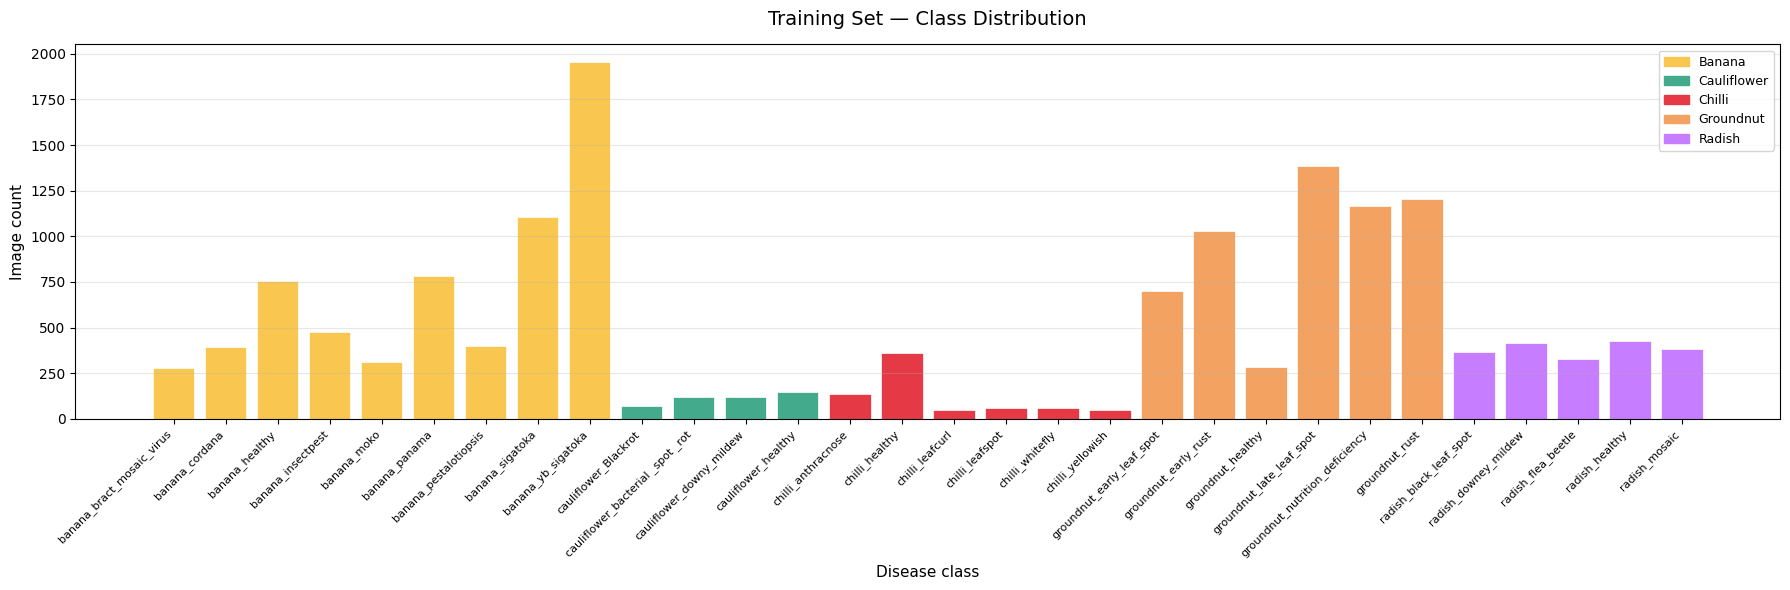

Total classes : 30
Train images  : 15,309
Valid images  : 4,374
Test  images  : 2,191


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 9 — Class distribution bar chart
# ═══════════════════════════════════════════════════════════

# Count images per class in training set
class_counts = {}
for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

# Colour each bar by crop
crop_colors = {
    'banana'     : '#F9C74F',
    'cauliflower': '#43AA8B',
    'chilli'     : '#E63946',
    'groundnut'  : '#F4A261',
    'radish'     : '#C77DFF',
}

bar_colors = []
for cls in class_counts:
    color = '#888888'
    for crop, col in crop_colors.items():
        if crop in cls.lower():
            color = col
            break
    bar_colors.append(color)

fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(class_counts.keys(), class_counts.values(),
       color=bar_colors, edgecolor='white', linewidth=0.5)

ax.set_title('Training Set — Class Distribution', fontsize=14, pad=14)
ax.set_xlabel('Disease class', fontsize=11)
ax.set_ylabel('Image count', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.grid(axis='y', alpha=0.3)

patches = [mpatches.Patch(color=c, label=k.title())
           for k, c in crop_colors.items()]
ax.legend(handles=patches, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150)
plt.show()

print(f'Total classes : {len(class_counts)}')
print(f'Train images  : {sum(class_counts.values()):,}')
print(f'Valid images  : {sum(len(os.listdir(os.path.join(VALID_DIR,c))) for c in os.listdir(VALID_DIR)):,}')
print(f'Test  images  : {sum(len(os.listdir(os.path.join(TEST_DIR,c))) for c in os.listdir(TEST_DIR)):,}')

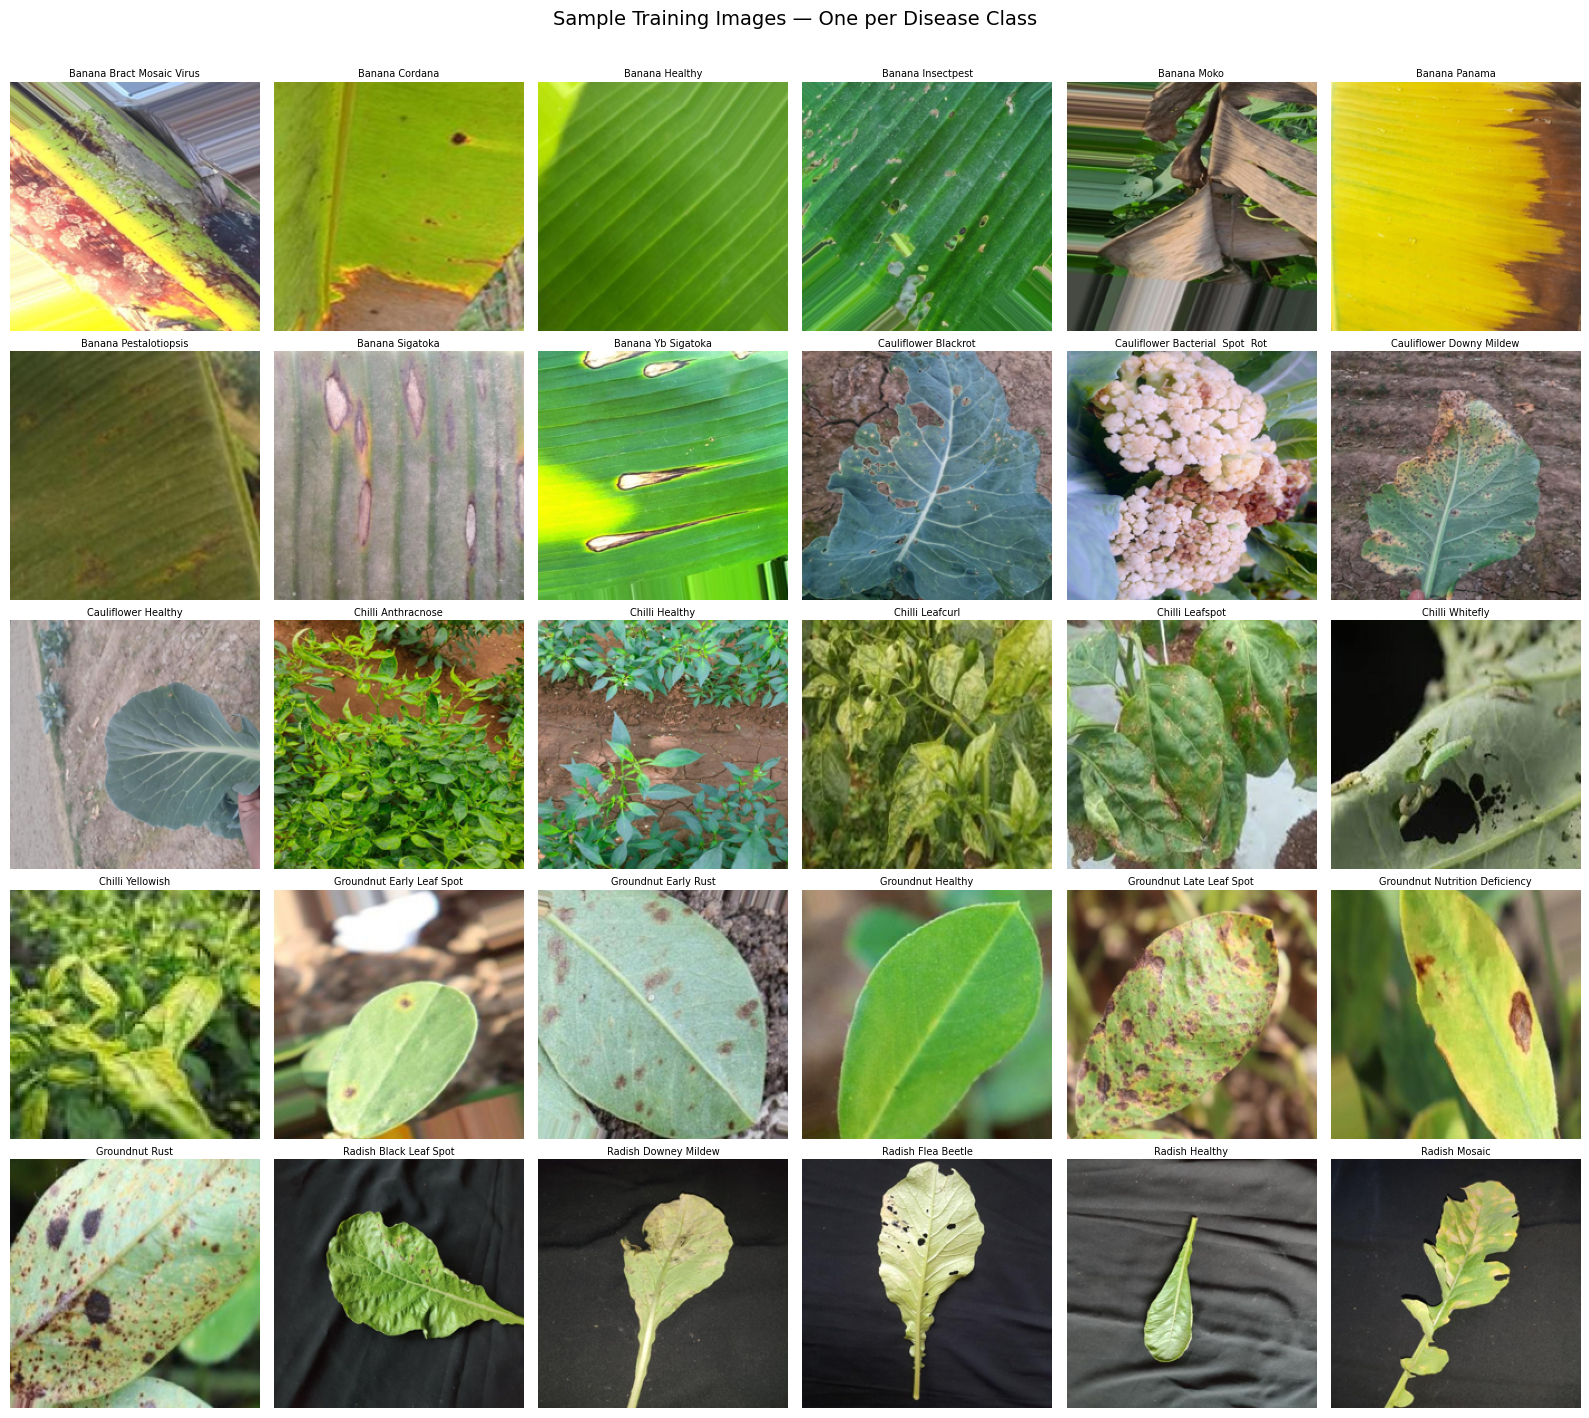

Showing 30 classes — one sample image each


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 10 — Sample images grid (one per class)
# ═══════════════════════════════════════════════════════════

all_classes = sorted(os.listdir(TRAIN_DIR))

# Show 5 rows x 6 cols = 30 images (one per class)
rows, cols = 5, 6
fig, axes = plt.subplots(rows, cols, figsize=(16, 14))
fig.suptitle('Sample Training Images — One per Disease Class',
             fontsize=14, y=1.01)

for ax, cls in zip(axes.flatten(), all_classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs     = os.listdir(cls_path)
    img_file = random.choice(imgs)
    img      = Image.open(os.path.join(cls_path, img_file)).convert('RGB')
    img      = img.resize((224, 224))

    ax.imshow(img)
    # Clean up label: replace underscores with spaces, title case
    label = cls.replace('_', ' ').title()
    ax.set_title(label, fontsize=7, pad=3)
    ax.axis('off')

# Hide any unused axes
for ax in axes.flatten()[len(all_classes):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=120)
plt.show()

print(f'Showing {len(all_classes)} classes — one sample image each')

In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 11 — Data loading with augmentation
# ═══════════════════════════════════════════════════════════
train_datagen = ImageDataGenerator(
    rescale            = 1.0/255,  # normalise pixels [0,255] → [0,1]
    rotation_range     = 20,       # random rotation ±20°
    width_shift_range  = 0.1,      # shift image left/right
    height_shift_range = 0.1,      # shift image up/down
    shear_range        = 0.1,      # slight shear distortion
    zoom_range         = 0.2,      # random zoom in/out
    horizontal_flip    = True      # mirror image left↔right
)

# ── Validation & Test — only normalise, no augmentation ───
eval_datagen = ImageDataGenerator(rescale=1.0/255)

# ── Create generators ─────────────────────────────────────
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,       # resize all images to 128x128
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = True,
    seed        = SEED
)

valid_gen = eval_datagen.flow_from_directory(
    VALID_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)

test_gen = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)

# ── Store class info ──────────────────────────────────────
NUM_CLASSES = train_gen.num_classes
CLASS_NAMES = list(train_gen.class_indices.keys())

# ── Save class names to JSON ──────────────────────────────
with open(CLASSES_PATH, 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)

print(f'Train samples  : {train_gen.samples:,}')
print(f'Valid samples  : {valid_gen.samples:,}')
print(f'Test  samples  : {test_gen.samples:,}')
print(f'Num classes    : {NUM_CLASSES}')
print(f'Batch size     : {BATCH_SIZE}')
print(f'Image size     : {IMG_SIZE}')
print(f'\nclass_names.json saved')
print(f'\nClass index mapping:')
for name, idx in train_gen.class_indices.items():
    print(f'  {idx:2d}: {name}')

Found 15309 images belonging to 30 classes.
Found 4374 images belonging to 30 classes.
Found 2191 images belonging to 30 classes.
Train samples  : 15,309
Valid samples  : 4,374
Test  samples  : 2,191
Num classes    : 30
Batch size     : 32
Image size     : (128, 128)

class_names.json saved

Class index mapping:
   0: banana_bract_mosaic_virus
   1: banana_cordana
   2: banana_healthy
   3: banana_insectpest
   4: banana_moko
   5: banana_panama
   6: banana_pestalotiopsis
   7: banana_sigatoka
   8: banana_yb_sigatoka
   9: cauliflower_Blackrot
  10: cauliflower_bacterial _spot _rot
  11: cauliflower_downy_mildew
  12: cauliflower_healthy
  13: chilli_anthracnose
  14: chilli_healthy
  15: chilli_leafcurl
  16: chilli_leafspot
  17: chilli_whitefly
  18: chilli_yellowish
  19: groundnut_early_leaf_spot
  20: groundnut_early_rust
  21: groundnut_healthy
  22: groundnut_late_leaf_spot
  23: groundnut_nutrition_deficiency
  24: groundnut_rust
  25: radish_black_leaf_spot
  26: radish_dow

In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 12 — Build CNN model
# ═══════════════════════════════════════════════════════════

def build_cnn(num_classes):
    model = models.Sequential([

        # ── Block 1 ───────────────────────────────────────
        layers.Conv2D(
            32, (3, 3), padding='same',
            kernel_regularizer=regularizers.l2(0.001),
            input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
        ),
        layers.Activation('relu'),      # ReLU — Module 4
        layers.MaxPooling2D(2, 2),

        # ── Block 2 ───────────────────────────────────────
        layers.Conv2D(
            64, (3, 3), padding='same',
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        # ── Block 3 ───────────────────────────────────────
        layers.Conv2D(
            128, (3, 3), padding='same',
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        # ── Classifier head ───────────────────────────────
        layers.Flatten(),

        # Fully connected layer — combines all features
        layers.Dense(
            256, activation='relu',
            kernel_regularizer=regularizers.l2(0.001)  # L2 — Module 4
        ),

        layers.Dropout(0.5),

        layers.Dense(num_classes, activation='softmax')  # Module 4
    ])
    return model


model = build_cnn(NUM_CLASSES)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,489,822 (32.39 MB)

 Trainable params: 8,489,822 (32.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 13 — Compile & Train
# ═══════════════════════════════════════════════════════════

# ── Optimizer: SGD with Momentum ───────────────
optimizer = tf.keras.optimizers.SGD(
    learning_rate = LR,        # 0.01
    momentum = MOMENTUM   # 0.9
)

# ── Compile ───────────────────────────────────────────────
model.compile(
    optimizer = optimizer,
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

# ── Callbacks ─────────────────────────────────────────────

# EarlyStopping: stops training when val_loss stops
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 6,
    restore_best_weights = True,  # revert to best epoch
    verbose = 1
)

# ReduceLROnPlateau: halves learning rate when stuck
reduce_lr = ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 3,
    min_lr   = 1e-6,
    verbose  = 1
)

print('Compiler settings:')
print(f'  Optimizer : SGD')
print(f'  LR        : {LR}')
print(f'  Momentum  : {MOMENTUM}')
print(f'  Loss      : categorical_crossentropy')
print(f'  Max epochs: {EPOCHS}')
print()
print('Starting training...')
print('─' * 60)

# ── Train ─────────────────────────────────────────────────
history = model.fit(
    train_gen,
    epochs          = EPOCHS,
    validation_data = valid_gen,
    callbacks       = [early_stop, reduce_lr],
    verbose         = 1
)

Compiler settings:
  Optimizer : SGD
  LR        : 0.01
  Momentum  : 0.9
  Loss      : categorical_crossentropy
  Max epochs: 30

Starting training...
────────────────────────────────────────────────────────────
Epoch 1/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 140s 278ms/step - accuracy: 0.2621 - loss: 3.0189 - val_accuracy: 0.3274 - val_loss: 2.6712 - learning_rate: 0.0100
Epoch 2/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 121s 253ms/step - accuracy: 0.4373 - loss: 2.3192 - val_accuracy: 0.5951 - val_loss: 1.8243 - learning_rate: 0.0100
Epoch 3/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 133s 277ms/step - accuracy: 0.5542 - loss: 1.8869 - val_accuracy: 0.6477 - val_loss: 1.6294 - learning_rate: 0.0100
Epoch 4/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 123s 256ms/step - accuracy: 0.6050 - loss: 1.6800 - val_accuracy: 0.6344 - val_loss: 1.5221 - learning_rate: 0.0100
Epoch 5/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 124s 258ms/step - accuracy: 0.6514 - loss: 1.5051 - val_accuracy: 0.6614 - val_loss: 1.4016 - learning_rate: 0.0100
Epoch 6

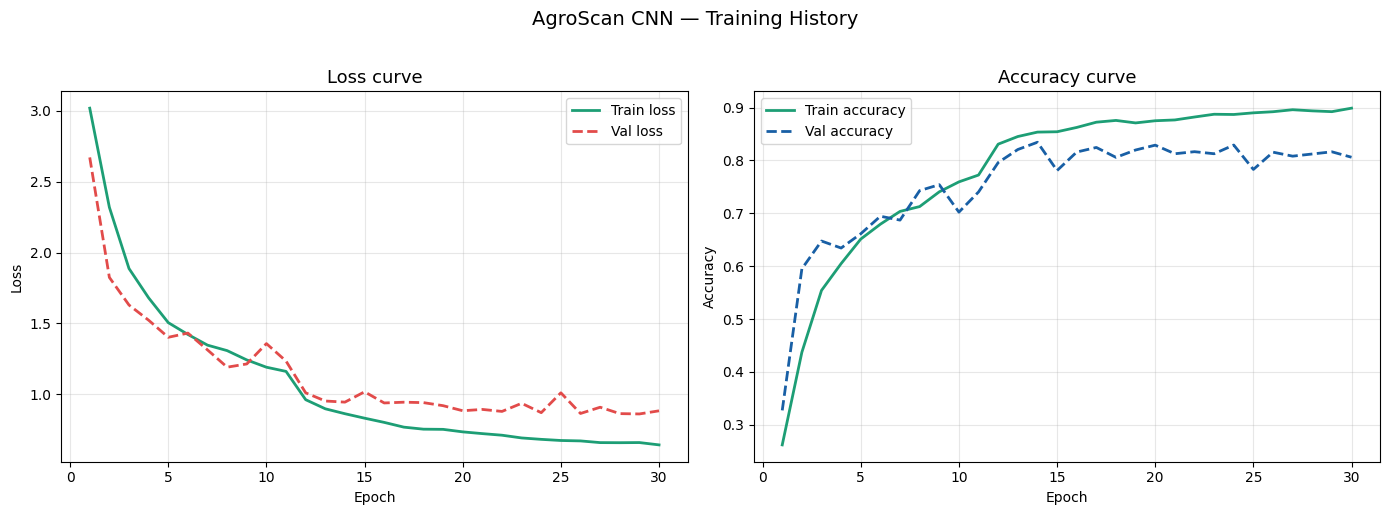

Best epoch        : 29
Best val accuracy : 83.4%
Best val loss     : 0.8605

Bias-Variance analysis:
  Final train acc : 89.9%
  Final val acc   : 80.6%
  Gap             : 9.3%
  Verdict         : Good fit — acceptable variance


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 14 — Loss & Accuracy curves
# ═══════════════════════════════════════════════════════════

epochs_ran = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss curve ────────────────────────────────────────────
axes[0].plot(epochs_ran, history.history['loss'],
             color='#1D9E75', linewidth=2, label='Train loss')
axes[0].plot(epochs_ran, history.history['val_loss'],
             color='#E24B4A', linewidth=2,
             linestyle='--', label='Val loss')
axes[0].set_title('Loss curve', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Accuracy curve ────────────────────────────────────────
axes[1].plot(epochs_ran, history.history['accuracy'],
             color='#1D9E75', linewidth=2, label='Train accuracy')
axes[1].plot(epochs_ran, history.history['val_accuracy'],
             color='#185FA5', linewidth=2,
             linestyle='--', label='Val accuracy')
axes[1].set_title('Accuracy curve', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('AgroScan CNN — Training History', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/content/loss_accuracy_curves.png', dpi=150,
            bbox_inches='tight')
plt.show()

# ── Summary ───────────────────────────────────────────────
best_epoch    = np.argmin(history.history['val_loss']) + 1
best_val_acc  = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])

print(f'Best epoch        : {best_epoch}')
print(f'Best val accuracy : {best_val_acc*100:.1f}%')
print(f'Best val loss     : {best_val_loss:.4f}')
print()
print('Bias-Variance analysis:')
final_train = history.history['accuracy'][-1]
final_val   = history.history['val_accuracy'][-1]
gap         = final_train - final_val
print(f'  Final train acc : {final_train*100:.1f}%')
print(f'  Final val acc   : {final_val*100:.1f}%')
print(f'  Gap             : {gap*100:.1f}%')
if gap < 0.05:
    print('  Verdict         : Excellent fit — very low variance')
elif gap < 0.10:
    print('  Verdict         : Good fit — acceptable variance')
elif gap < 0.15:
    print('  Verdict         : Slight overfitting — manageable')
else:
    print('  Verdict         : Overfitting detected')

In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 15 — Confusion Matrix & Classification Report
# ═══════════════════════════════════════════════════════════

# ── Predict on validation set ─────────────────────────────
print('Running predictions on validation set...')
valid_gen.reset()
y_pred_probs = model.predict(valid_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = valid_gen.classes

# ── Classification Report ─────────────────────────────────
print('\n── Classification Report (Validation Set) ──────────────')
print(classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    digits=3
))

overall_acc = np.mean(y_pred == y_true)
print(f'Overall Validation Accuracy : {overall_acc*100:.2f}%')

Running predictions on validation set...
137/137 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step

── Classification Report (Validation Set) ──────────────
                                  precision    recall  f1-score   support

       banana_bract_mosaic_virus      0.750     0.675     0.711        80
                  banana_cordana      0.981     0.955     0.968       111
                  banana_healthy      0.932     0.889     0.910       216
               banana_insectpest      0.776     0.698     0.735       139
                     banana_moko      0.824     0.795     0.809        88
                   banana_panama      0.786     0.674     0.726       224
           banana_pestalotiopsis      0.892     0.868     0.880       114
                 banana_sigatoka      0.449     0.885     0.596       174
              banana_yb_sigatoka      0.784     0.952     0.860       558
            cauliflower_Blackrot      0.950     0.950     0.950        20
cauliflower_bacterial _spot _rot      0.656

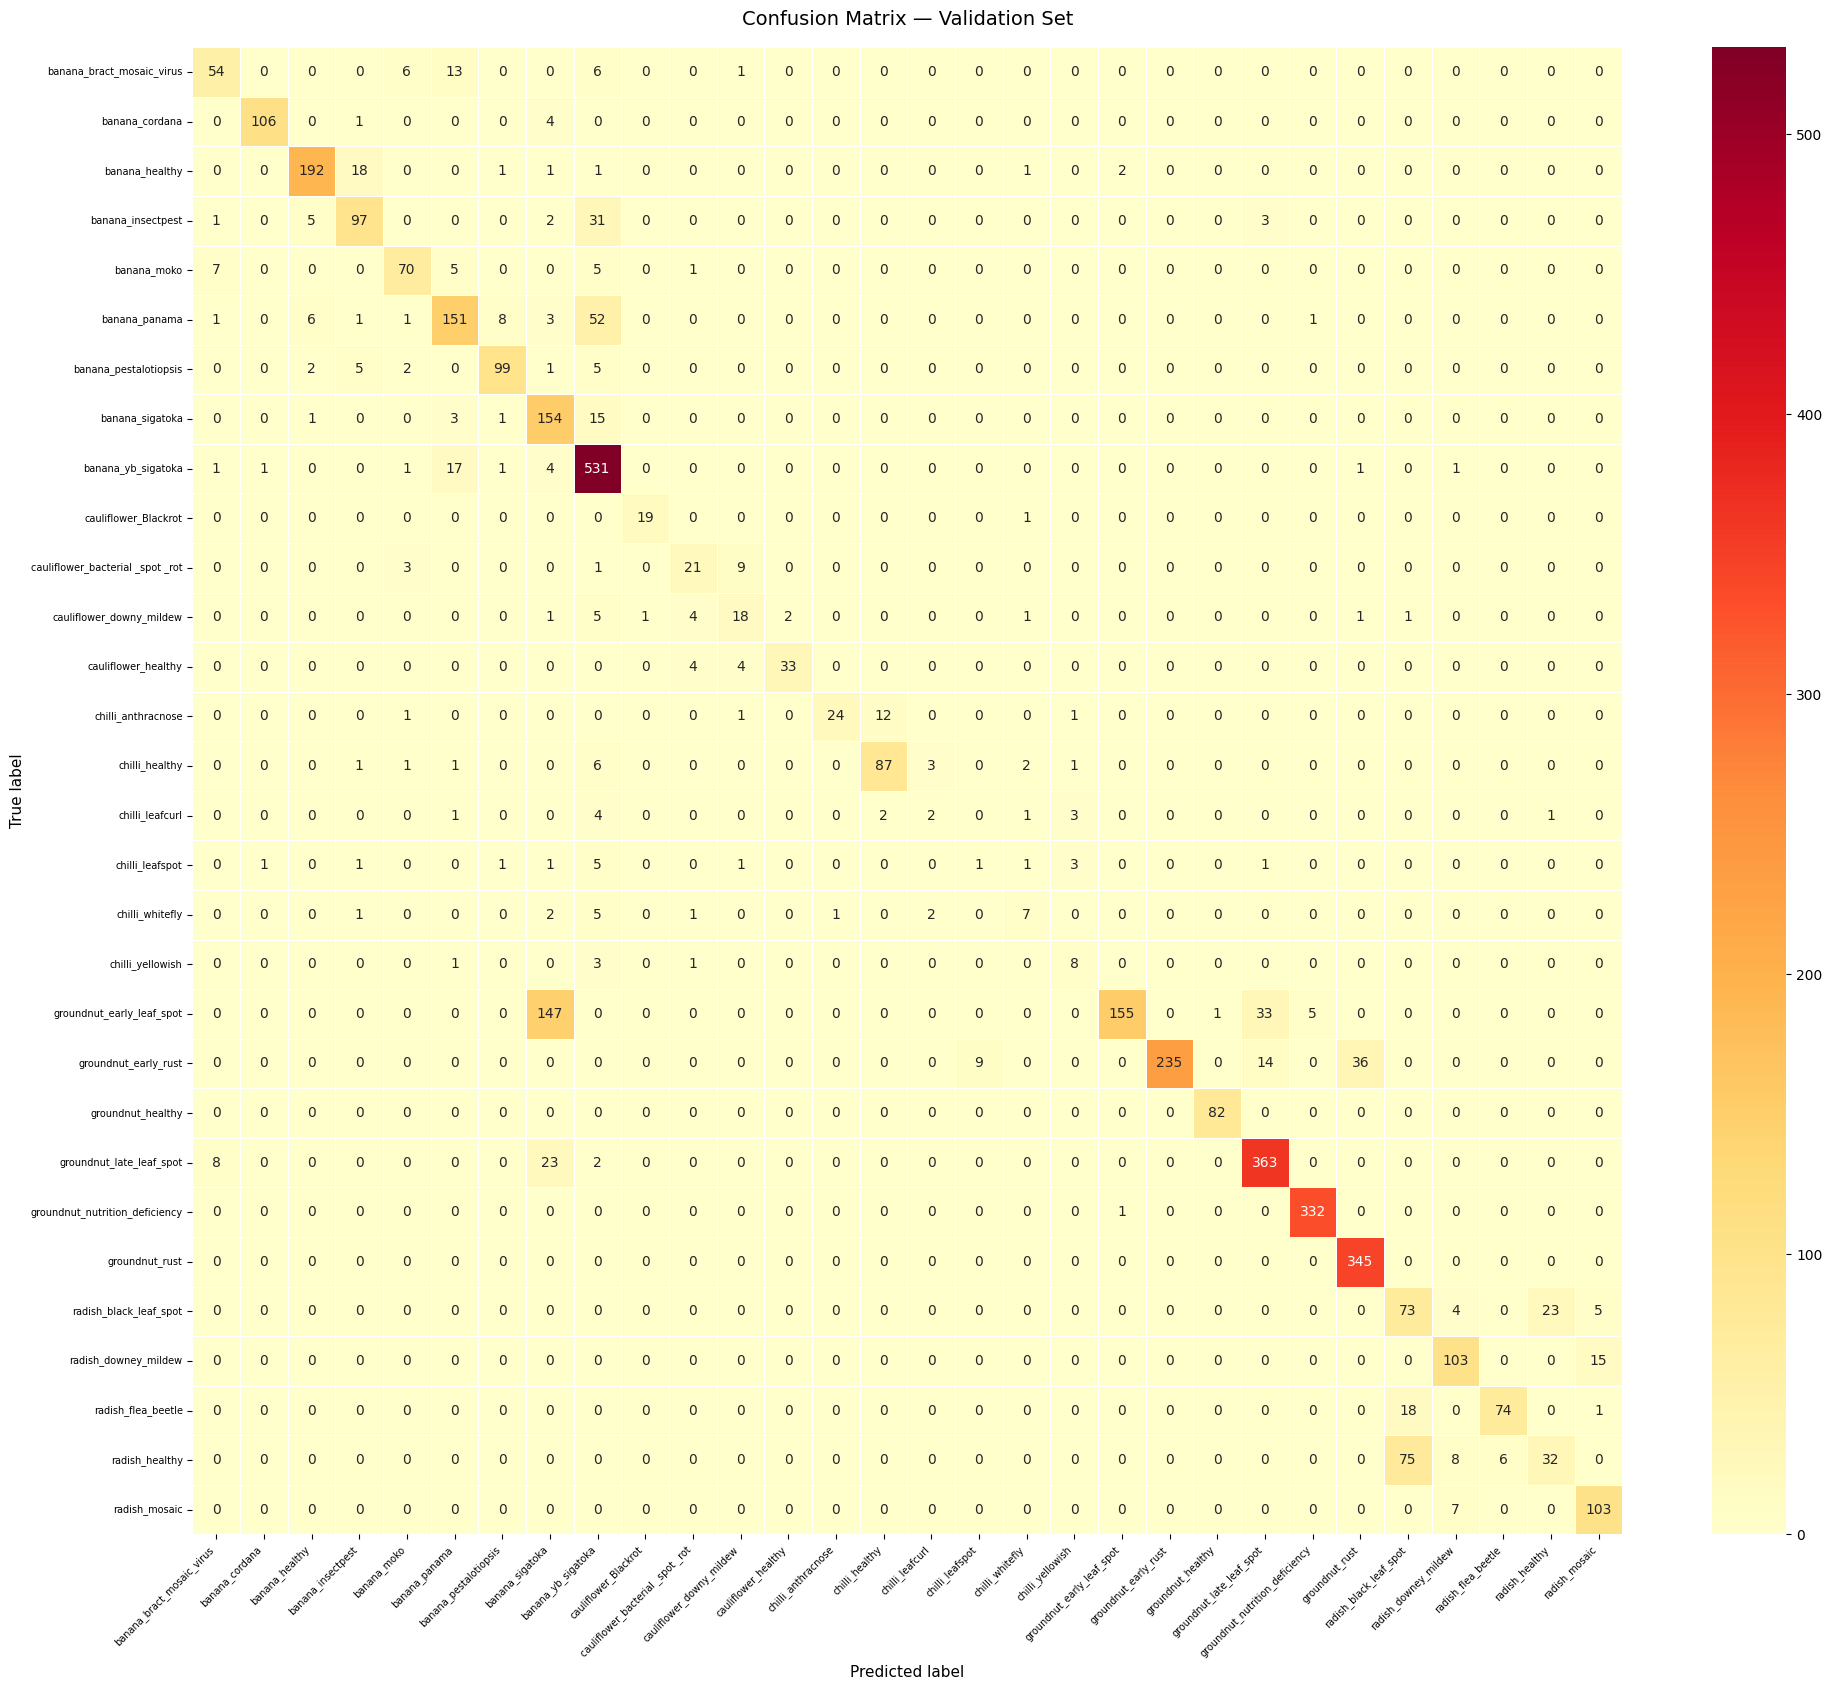

── Per-class accuracy ───────────────────────────────────

Top 5 best predicted classes:
  groundnut_rust                                100.0%
  groundnut_healthy                             100.0%
  groundnut_nutrition_deficiency                99.7%
  banana_cordana                                95.5%
  banana_yb_sigatoka                            95.2%

Bottom 5 hardest classes:
  groundnut_early_leaf_spot                     45.5%
  chilli_whitefly                               36.8%
  radish_healthy                                26.4%
  chilli_leafcurl                               14.3%
  chilli_leafspot                               6.2%


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 16 — Confusion Matrix Heatmap
# ═══════════════════════════════════════════════════════════

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 17))
sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'YlOrRd',
    xticklabels = CLASS_NAMES,
    yticklabels = CLASS_NAMES,
    linewidths  = 0.4,
    linecolor   = 'white'
)

plt.title('Confusion Matrix — Validation Set', fontsize=14, pad=16)
plt.ylabel('True label', fontsize=11)
plt.xlabel('Predicted label', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150,
            bbox_inches='tight')
plt.show()

# ── Highlight best and worst performing classes ───────────
print('── Per-class accuracy ───────────────────────────────────')
per_class_acc = cm.diagonal() / cm.sum(axis=1)
sorted_idx    = np.argsort(per_class_acc)[::-1]

print('\nTop 5 best predicted classes:')
for idx in sorted_idx[:5]:
    print(f'  {CLASS_NAMES[idx]:<45} {per_class_acc[idx]*100:.1f}%')

print('\nBottom 5 hardest classes:')
for idx in sorted_idx[-5:]:
    print(f'  {CLASS_NAMES[idx]:<45} {per_class_acc[idx]*100:.1f}%')

In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 17 — Final evaluation on Test Set
# ═══════════════════════════════════════════════════════════

print('Running predictions on test set...')
test_gen.reset()
y_test_probs = model.predict(test_gen, verbose=1)
y_test_pred  = np.argmax(y_test_probs, axis=1)
y_test_true  = test_gen.classes

# ── Classification Report ─────────────────────────────────
print('\n── Classification Report (Test Set) ────────────────────')
print(classification_report(
    y_test_true, y_test_pred,
    target_names=CLASS_NAMES,
    digits=3
))

test_acc = np.mean(y_test_pred == y_test_true)
print(f'Overall Test Accuracy : {test_acc*100:.2f}%')

# ── Summary table ─────────────────────────────────────────
print('\n── Final Results Summary ────────────────────────────────')
print(f'  Train Accuracy      : {max(history.history["accuracy"])*100:.2f}%')
print(f'  Validation Accuracy : {max(history.history["val_accuracy"])*100:.2f}%')
print(f'  Test Accuracy       : {test_acc*100:.2f}%')
print(f'  Best Epoch          : {np.argmin(history.history["val_loss"])+1}')
print(f'  Total Classes       : {NUM_CLASSES}')
print(f'  Total Test Images   : {test_gen.samples:,}')

Running predictions on test set...
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step

── Classification Report (Test Set) ────────────────────
                                  precision    recall  f1-score   support

       banana_bract_mosaic_virus      0.775     0.775     0.775        40
                  banana_cordana      0.949     1.000     0.974        56
                  banana_healthy      0.852     0.852     0.852       108
               banana_insectpest      0.758     0.704     0.730        71
                     banana_moko      0.812     0.867     0.839        45
                   banana_panama      0.812     0.586     0.681       111
           banana_pestalotiopsis      0.762     0.828     0.793        58
                 banana_sigatoka      0.500     0.852     0.630        88
              banana_yb_sigatoka      0.834     0.989     0.905       279
            cauliflower_Blackrot      1.000     0.556     0.714         9
cauliflower_bacterial _spot _rot      0.667     0.25

In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 18 — Save model and class names
# ═══════════════════════════════════════════════════════════

# ── Saving trained model ────────────────────────────────────
model.save(MODEL_PATH)
print(f'Model saved      : {MODEL_PATH}')

# ── Saving class names ──────────────────────────────────────
with open(CLASSES_PATH, 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)
print(f'Class names saved: {CLASSES_PATH}')

# ── Verifying file sizes ─────────────────────────────────────
model_size = os.path.getsize(MODEL_PATH) / (1024*1024)
class_size = os.path.getsize(CLASSES_PATH) / 1024

print(f'\nFile sizes:')
print(f'  plant_disease_model.h5  : {model_size:.1f} MB')
print(f'  class_names.json        : {class_size:.1f} KB')

# ── Listing all saved output files ───────────────────────────
print(f'\nAll output files:')
output_files = [
    MODEL_PATH,
    CLASSES_PATH,
    '/content/class_distribution.png',
    '/content/sample_images.png',
    '/content/loss_accuracy_curves.png',
    '/content/confusion_matrix.png',
]
for f in output_files:
    exists = os.path.exists(f)
    size   = os.path.getsize(f)/1024 if exists else 0
    status = f'{size:.0f} KB' if exists else 'NOT FOUND'
    print(f'  {"Yes" if exists else "No"}  {f:<45} {status}')

Model saved      : /content/plant_disease_model.h5
Class names saved: /content/class_names.json

File sizes:
  plant_disease_model.h5  : 64.8 MB
  class_names.json        : 0.7 KB

All output files:
  Yes  /content/plant_disease_model.h5               66375 KB
  Yes  /content/class_names.json                     1 KB
  Yes  /content/class_distribution.png               179 KB
  Yes  /content/sample_images.png                    4092 KB
  Yes  /content/loss_accuracy_curves.png             111 KB
  Yes  /content/confusion_matrix.png                 356 KB


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 19 — Downloading all files to local machine
# ═══════════════════════════════════════════════════════════
from google.colab import files

output_files = [
    '/content/plant_disease_model.h5',
    '/content/class_names.json',
    '/content/class_distribution.png',
    '/content/sample_images.png',
    '/content/loss_accuracy_curves.png',
    '/content/confusion_matrix.png',
]

print('Downloading files...\n')
for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f'Downloaded: {f}')
    else:
        print(f'Not found: {f}')

print('\nAll done!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: /content/plant_disease_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: /content/loss_accuracy_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: /content/confusion_matrix.png

All done!


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 20 — Backup all files to Google Drive
# ═══════════════════════════════════════════════════════════

DRIVE_OUTPUT = '/content/drive/MyDrive/Colab_Notebooks/AIML_PROJECT/AgroScan_Output'
os.makedirs(DRIVE_OUTPUT, exist_ok=True)

output_files = [
    '/content/plant_disease_model.h5',
    '/content/class_names.json',
    '/content/class_distribution.png',
    '/content/sample_images.png',
    '/content/loss_accuracy_curves.png',
    '/content/confusion_matrix.png',
]

print('Backing up to Google Drive...\n')
for f in output_files:
    if os.path.exists(f):
        dest = os.path.join(DRIVE_OUTPUT, os.path.basename(f))
        shutil.copy2(f, dest)
        print(f'{os.path.basename(f)}')
    else:
        print(f'Not found: {f}')

print(f'\nAll files backed up to:')
print(f'   {DRIVE_OUTPUT}')
print(f'\nContents:')
for f in os.listdir(DRIVE_OUTPUT):
    size = os.path.getsize(os.path.join(DRIVE_OUTPUT, f)) / 1024
    print(f'  {f:<40} {size:.0f} KB')

Backing up to Google Drive...

plant_disease_model.h5
class_names.json
class_distribution.png
sample_images.png
loss_accuracy_curves.png
confusion_matrix.png

All files backed up to:
   /content/drive/MyDrive/Colab_Notebooks/AIML_PROJECT/AgroScan_Output

Contents:
  plant_disease_model.h5                   66375 KB
  class_names.json                         1 KB
  class_distribution.png                   179 KB
  sample_images.png                        4092 KB
  loss_accuracy_curves.png                 111 KB
  confusion_matrix.png                     356 KB


In [ ]:
!pip install streamlit tensorflow pillow pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 113.9 MB/s eta 0:00:00


In [ ]:
# ═══════════════════════════════════════════════════════════
# Redefining all paths after session reset
# ═══════════════════════════════════════════════════════════
import os, shutil
from google.colab import drive

# Mount Drive if not already mounted
drive.mount('/content/drive')

# ── Redefine all Drive output paths ───────────────────────
DRIVE_OUT       = '/content/drive/MyDrive/Colab_Notebooks/AIML_PROJECT/AgroScan_Output'
MODEL_PATH      = os.path.join(DRIVE_OUT, 'plant_disease_model.h5')
BEST_MODEL_PATH = os.path.join(DRIVE_OUT, 'best_model.h5')
CLASSES_PATH    = os.path.join(DRIVE_OUT, 'class_names.json')
APP_PATH        = os.path.join(DRIVE_OUT, 'app.py')
DIST_PLOT       = os.path.join(DRIVE_OUT, 'class_distribution.png')
SAMPLE_PLOT     = os.path.join(DRIVE_OUT, 'sample_images.png')
AUG_PLOT        = os.path.join(DRIVE_OUT, 'augmented_samples.png')
CURVES_PLOT     = os.path.join(DRIVE_OUT, 'loss_accuracy_curves.png')
CM_PLOT         = os.path.join(DRIVE_OUT, 'confusion_matrix.png')
INFER_PLOT      = os.path.join(DRIVE_OUT, 'inference_result.png')

# ── Verify all files exist on Drive ───────────────────────
print('Checking files on Drive:\n')
all_files = [
    MODEL_PATH, CLASSES_PATH, APP_PATH,
    DIST_PLOT, SAMPLE_PLOT, AUG_PLOT,
    CURVES_PLOT, CM_PLOT, INFER_PLOT
]
all_good = True
for f in all_files:
    exists = os.path.exists(f)
    size   = os.path.getsize(f)/1024 if exists else 0
    status = f'FOUNT  {size:>8.0f} KB' if exists else 'NOT FOUND'
    print(f'  {status}  {os.path.basename(f)}')
    if not exists:
        all_good = False

if all_good:
    print('\nAll files found. Ready to launch Streamlit.')
else:
    print('\nSome files missing — you may need to retrain.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking files on Drive:

  ✅     66375 KB  plant_disease_model.h5
  ✅         1 KB  class_names.json
  ✅        11 KB  app.py
  ✅       179 KB  class_distribution.png
  ✅      4092 KB  sample_images.png
  ❌  NOT FOUND  augmented_samples.png
  ✅       111 KB  loss_accuracy_curves.png
  ✅       356 KB  confusion_matrix.png
  ❌  NOT FOUND  inference_result.png

Some files missing — you may need to retrain.


In [ ]:
# ═══════════════════════════════════════════════════════════
# FIX CELL 1 — Correct all paths to match actual files
# ═══════════════════════════════════════════════════════════
import os, shutil, json
from google.colab import drive

DRIVE_OUT = '/content/drive/MyDrive/Colab_Notebooks/AIML_PROJECT/AgroScan_Output'

# ── Use .h5 since that's what was actually saved ──────────
MODEL_PATH = os.path.join(DRIVE_OUT, 'plant_disease_model.h5')
CLASSES_PATH = os.path.join(DRIVE_OUT, 'class_names.json')
APP_PATH = os.path.join(DRIVE_OUT, 'app.py')
CURVES_PLOT = os.path.join(DRIVE_OUT, 'loss_accuracy_curves.png')
CM_PLOT = os.path.join(DRIVE_OUT, 'confusion_matrix.png')
DIST_PLOT = os.path.join(DRIVE_OUT, 'class_distribution.png')
SAMPLE_PLOT = os.path.join(DRIVE_OUT, 'sample_images.png')

print('Paths updated to match actual saved files')
print(f'Model : {os.path.basename(MODEL_PATH)}')
print(f'Classes: {os.path.basename(CLASSES_PATH)}')

Paths updated to match actual saved files
Model : plant_disease_model.h5
Classes: class_names.json
